In [18]:
import numpy as np
import pandas as pd
from pylab import *
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pylab import *
from sequana import FastA
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import random
from collections import defaultdict
from sklearn.metrics import classification_report


In [19]:
centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}


In [20]:
f = FastA("../../data/Fasta/genome.fasta")

In [21]:
def one_hot_encoding(x):
    if x == 'A':
        return np.array([1,0,0,0])
    elif x == 'C':
        return np.array([0,1,0,0])
    elif x == 'G':
        return np.array([0,0,1,0])
    elif x == 'T':
        return np.array([0,0,0,1])
    else:
        return np.array([0,0,0,0])
        

In [22]:
SIZE=3000

In [23]:
def get_true_positive(size=3000):
    data = []
    for chrom in range(1,36+1):
        start, stop = centromeres[str(chrom)]
        if f.names[0] == "1":
            seq = f.sequences[f.names.index(str(chrom))]
        else:
            seq = f.sequences[chrom-1]
            
        if stop-start != 3000:
            stop = start + size
        # flip to get more positives
        data.append([one_hot_encoding(x) for x in seq[start:stop]])
        data.append([one_hot_encoding(x) for x in seq[start:stop][::-1]])
        

    return data
positives = get_true_positive(SIZE)

In [24]:
lengths = f.get_lengths_as_dict()


In [25]:

##################################### WARNING #############################################
############################### REMOVE FALSE NEGATIVE (centromeres) #######################

def get_true_negatives(N=1000,size=3000,seed=42):
    data = []
    positions = defaultdict(list)
    random.seed(seed)

    # get the random combos first
    for i in tqdm(range(N)):
        chrom = random.randint(1,36)
        N = lengths[str(chrom)]
        pos = random.randint(1, N-size)
        start, stop = centromeres[str(chrom)]
        if pos>start and pos<stop:
            pass # this is a centromeres so not a negative
        else:
            positions[chrom].append(pos)
        
        
    for chrom in tqdm(positions.keys()):
        if f.names[0] == "1":
            seq = f.sequences[f.names.index(str(chrom))]
        else:
            seq = f.sequences[chrom-1]
        for position in positions[chrom]:
            data.append([one_hot_encoding(x) for x in seq[position:position+size]])
    return data

    #negatives = get_true_negatives(N=10000, size=SIZE)

In [26]:
f = FastA("../../data/Fasta/genome.fasta")

negatives = get_true_negatives(N=10000, size=SIZE,seed=8)


X_pos = positives
X_neg = negatives


# Create label arrays
y_pos = [1] * len(X_pos)
y_neg = [0] * len(X_neg)

# Combine and shuffle
X = np.array(X_pos + X_neg)  # shape: (N, 3000, 4)
y = np.array(y_pos + y_neg)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


layer_size=32

model = models.Sequential([
    layers.Input(shape=(SIZE, 4)),
    layers.Conv1D(layer_size,15, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(layer_size*2, 10, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(layer_size, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

seed = 42

tf.random.set_seed(seed)

tf.config.experimental.enable_op_determinism()
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    class_weight={0: 1, 1: len(y_neg)/len(y_pos)},  # handle imbalance
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


y_pred = model.predict(X_test) > 0.2
report = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    'f1_score': report['1']['f1-score'],
    'precision': report['1']['precision'],
    'recall': report['1']['recall']
}




100%|███████████████████████████████████████████| 36/36 [00:33<00:00,  1.07it/s]


Epoch 1/40


2025-07-30 14:16:09.146227: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 769536000 exceeds 10% of free system memory.
2025-07-30 14:16:09.631355: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 769536000 exceeds 10% of free system memory.
2025-07-30 14:16:10.043613: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatase

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4924 - loss: 1.6654

2025-07-30 14:16:52.209493: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy: 0.4929 - loss: 1.6642 - val_accuracy: 0.0549 - val_loss: 0.7694
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 78s 157ms/step - accuracy: 0.4997 - loss: 1.3546 - val_accuracy: 0.9147 - val_loss: 0.3363
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.8627 - loss: 0.5603 - val_accuracy: 0.9950 - val_loss: 0.0337
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 167ms/step - accuracy: 0.9641 - loss: 0.1867 - val_accuracy: 0.9915 - val_loss: 0.0355
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.9886 - loss: 0.0662 - val_accuracy: 0.9955 - val_loss: 0.0176
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.9931 - loss: 0.0391 - val_accuracy: 0.9960 - val_loss: 0.0132
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.9954 - loss: 0.0262 - val_accuracy: 0.9965 - val_loss: 0.0116
Epoch 8/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.9969 - loss: 0.0174 - val

2025-07-30 14:30:21.993970: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


In [10]:
y_pred = model.predict(X_test) > 0.2
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1991
           1       0.82      1.00      0.90        14

    accuracy                           1.00      2005
   macro avg       0.91      1.00      0.95      2005
weighted avg       1.00      1.00      1.00      2005



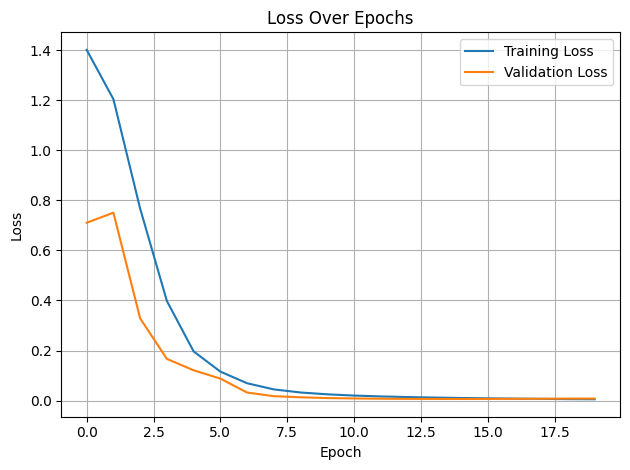

In [11]:
import matplotlib.pyplot as plt


# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


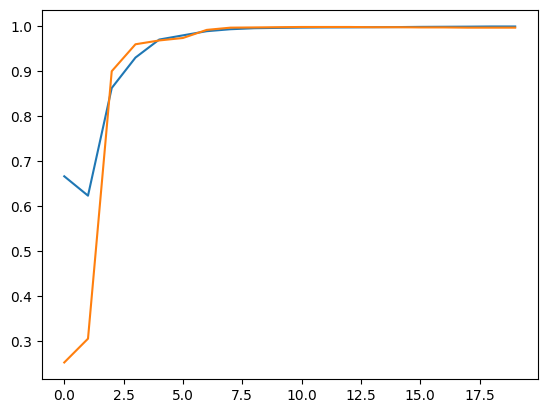

In [12]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


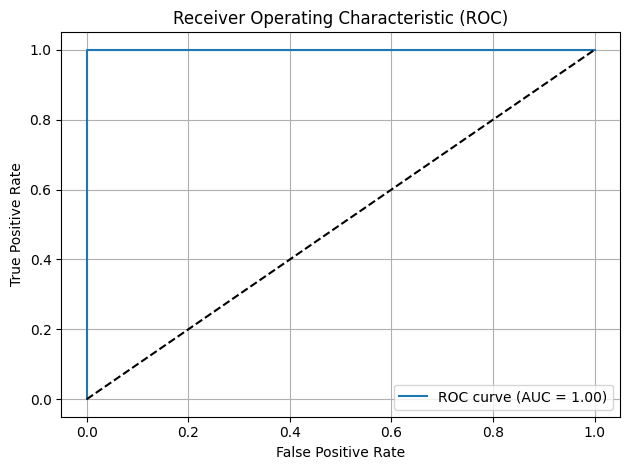

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict(X_test).ravel()  # get raw probabilities

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


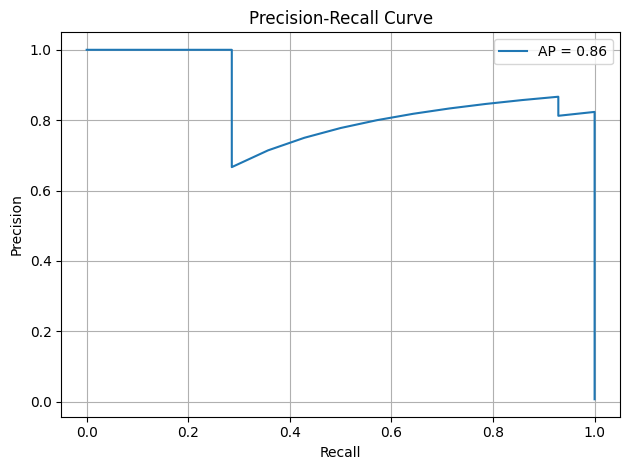

In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
import numpy as np

def predict_sliding_windows(seq, model, window_size=3000, step=1500):
    
    scores = []
    positions = []

    # Slide through the sequence
    for i in tqdm(range(0, len(seq) - window_size + 1, step)):
        chunk = seq[i:i + window_size]
        
        # One-hot encoded? Already a list of np.array([1,0,0,0]) per base
        # Otherwise, if string-based: encode here
        chunk = [one_hot_encoding(x) for x in chunk]
        X = np.array(chunk).reshape(1, window_size, 4)  # batch of 1
        prob = model.predict(X, verbose=0)[0][0]
        
        scores.append(prob)
        positions.append((i, i + window_size))

    return positions, scores


In [16]:
all_scores = {}
results = {}


100%|███████████████████████████████████████| 1896/1896 [03:15<00:00,  9.68it/s]


36 (2590500, 2593500) 0.9623771


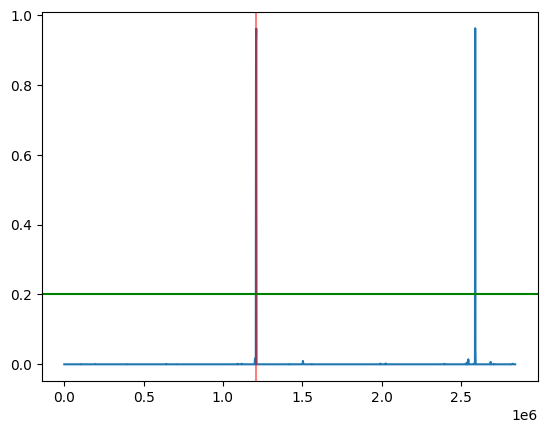

In [27]:
f = FastA("../../data/Fasta/genome.fasta")

centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")


centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(36,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
   # savefig(f"./donovaniV2/16_5/CNN1_{chrom}_Ldono.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

  0%|                                           | 1/492 [00:00<00:52,  9.42it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 306


100%|█████████████████████████████████████████| 492/492 [00:41<00:00, 11.80it/s]


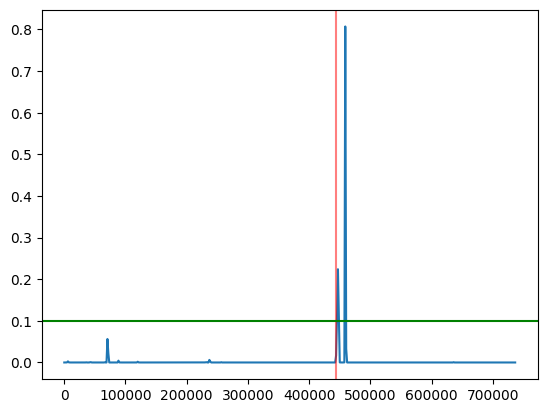

In [20]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.1, color='g')


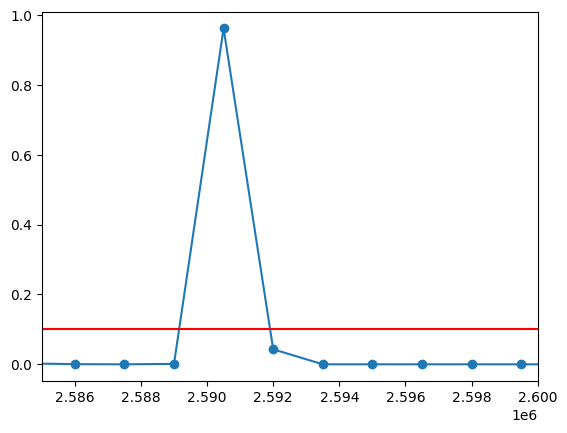

In [31]:
plot([x[0] for  x in positions], scores, 'o-')
xlim([2585000,2600000])
axhline(0.1, color='r')


100%|███████████████████████████████████████████| 75/75 [00:06<00:00, 11.99it/s]


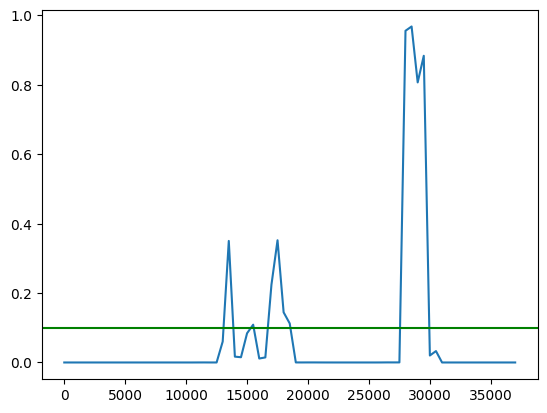

In [26]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    seq = seq[430000:470000]
    positions, scores = predict_sliding_windows(seq, model,SIZE,500)
    _ = plot([x[0] for x in positions], scores)
    axhline(0.1, color='g')

In [ ]:
#f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
f = FastA("../../data/Fasta/genome.fasta")

centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.1, color='g')
    savefig(f"./falsePosi/donovani/CNN1_{chrom}_Ldo.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)